In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

In [2]:
# Load dataset
twitter = pd.read_csv("C:\\Data_Science\\Prodigy_Tasks\\data-science-datasets\\Task 4\\twitter_training.csv", header=None, names=["ID", "Entity", "Sentiment", "Text"])

In [3]:
twitter.shape

(74682, 4)

In [4]:
twitter.describe(include ='all')

,ID,Entity,Sentiment,Text
count,74682.000000,74682,74682,73996
unique,NaN,32,4,69491
top,NaN,TomClancysRainbowSix,Negative,"At the same time, despite the fact that there ..."
freq,NaN,2400,22542,172
mean,6432.586165,NaN,NaN,NaN
std,3740.427870,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3195.000000,NaN,NaN,NaN
50%,6422.000000,NaN,NaN,NaN
75%,9601.000000,NaN,NaN,NaN


In [5]:
twitter.describe(include ='object')

,Entity,Sentiment,Text
count,74682,74682,73996
unique,32,4,69491
top,TomClancysRainbowSix,Negative,"At the same time, despite the fact that there ..."
freq,2400,22542,172


In [6]:
print(twitter.info())
print(twitter["Sentiment"].value_counts())
print(twitter["Entity"].value_counts().head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64
Entity
TomClancysRainbowSix         2400
MaddenNFL                    2400
Microsoft                    2400
LeagueOfLegends              2394
CallOfDuty                   2394
Verizon                      2382
CallOfDutyBlackopsColdWar    2376
ApexLegends                  2376
Facebook                     2370
WorldOfCraft                 2364
Name: count, dtype: int64


In [7]:
twitter.isna().sum()

ID             0
Entity         0
Sentiment      0
Text         686
dtype: int64

In [9]:
twitter.dropna(subset=["Text"])

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


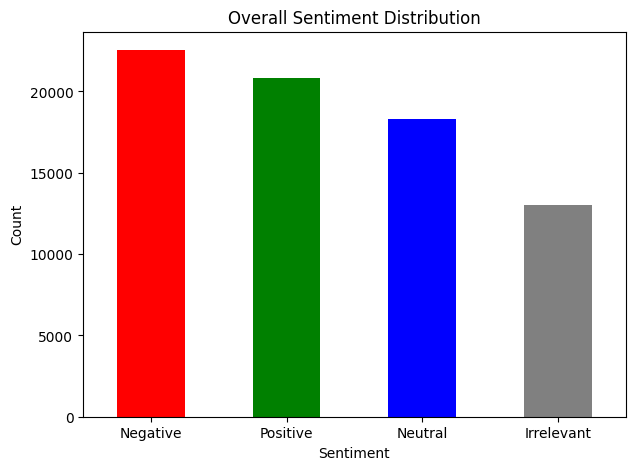

In [10]:
sentiment_counts = twitter["Sentiment"].value_counts()

plt.figure(figsize=(7,5))
sentiment_counts.plot(kind='bar', color=['red','green','blue','gray'])
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

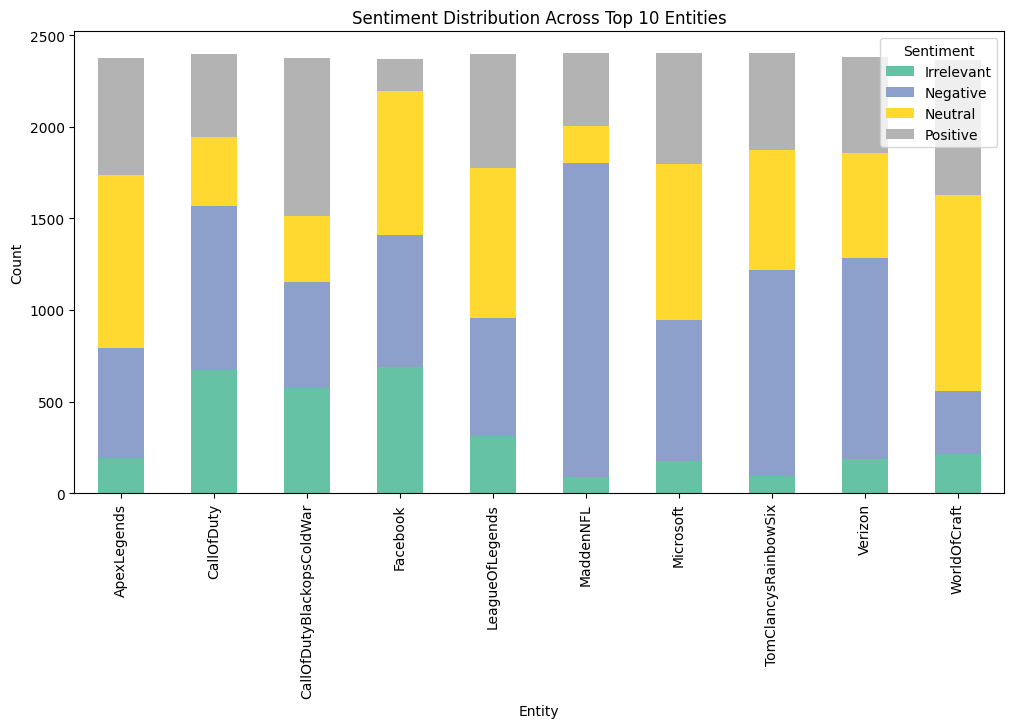

In [11]:
# Pick top 10 entities
top_entities = twitter["Entity"].value_counts().head(10).index

# Group by entity and sentiment
entity_sentiment = (
    twitter[twitter["Entity"].isin(top_entities)]
    .groupby(["Entity","Sentiment"])
    .size()
    .unstack(fill_value=0)
)

# Stacked bar plot
entity_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Set2"
)
plt.title("Sentiment Distribution Across Top 10 Entities")
plt.ylabel("Count")
plt.xlabel("Entity")
plt.legend(title="Sentiment")
plt.show()


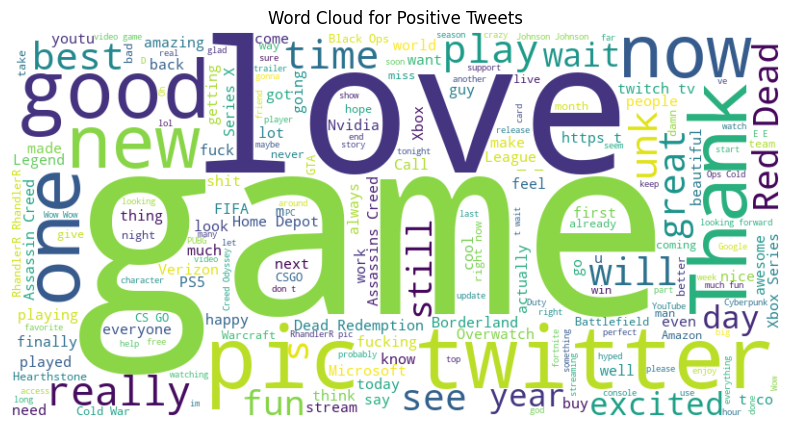

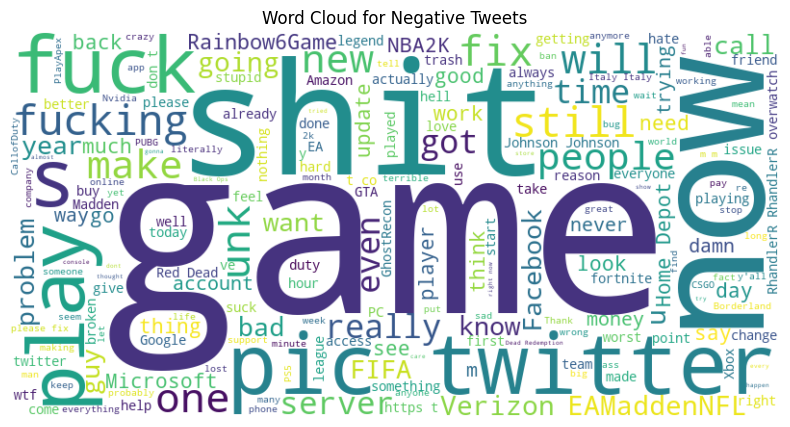

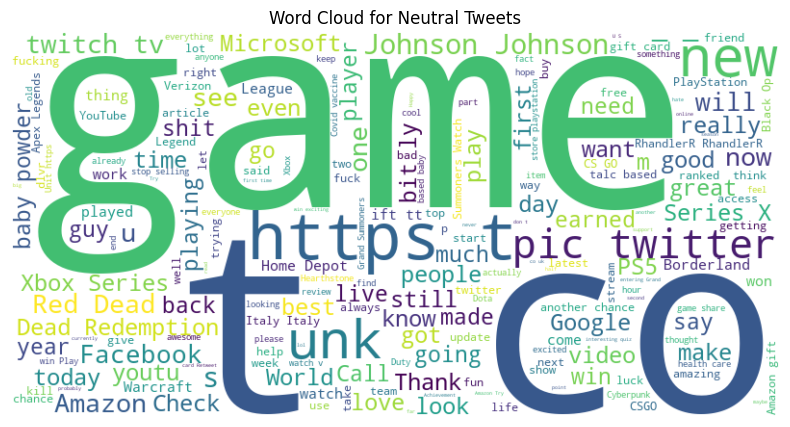

In [12]:
from wordcloud import WordCloud

for sentiment in ["Positive", "Negative", "Neutral"]:
    text = " ".join(twitter[twitter["Sentiment"]==sentiment]["Text"].dropna().tolist())
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {sentiment} Tweets")
    plt.show()

